This Notebook contains the Maximal Likelihood Fit Exercise.Everything is done utilizing Minuit as discussed in class

Part 1a:

In [2]:
import numpy as np
import scipy.stats as stats
from scipy.stats import truncexpon
from scipy.stats import truncnorm
from scipy.stats import chi2
from scipy.stats import norm
import iminuit
from iminuit import Minuit
import matplotlib.pyplot as plt
from matplotlib import container
plt.rcParams["font.size"] = 10
print("iminuit version:", iminuit.__version__)

iminuit version: 2.32.0


The functional form of Source+Background is: $f(x,\theta,\xi )=\theta\frac{1}{\sqrt{2\pi\sigma^{2}}}exp[\frac{-(x-\mu)^{2}}{2\sigma^{2}}]+\frac{(1-\theta)}{\xi}exp[\frac{-x}{\xi}]$. Here the source is the Gausiian and Background is Poissonian.



In [3]:
# define pdf and generate data
np.random.seed(seed=1234567)  
theta_true = 0.2
mu_true = 10.0
sigma_true = 2.0
xi_true = 5.0

xMin = 0.0
xMax = 20.0
numVal = 2000

x=np.zeros(numVal)

def f(x, par):
    theta   = par[0]
    mu      = par[1]
    sigma   = par[2]
    xi      = par[3]
    fs = stats.truncnorm.pdf(x, a=(xMin-mu)/sigma, b=(xMax-mu)/sigma, loc=mu, scale=sigma)
    fb = stats.truncexpon.pdf(x, b=(xMax-xMin)/xi, loc=xMin, scale=xi)
    return theta*fs + (1-theta)*fb

for i in range(numVal):
    a=np.random.uniform(0,1)
    if a<theta_true:
        x[i] = truncnorm.rvs(a=(xMin-mu_true)/sigma_true, b=(xMax-mu_true)/sigma_true, loc=mu_true, scale=sigma_true)
    else:
        x[i] = truncexpon.rvs(b=(xMax-xMin)/xi_true, loc=xMin, scale=xi_true)
print(x)

[ 0.03768309  9.02579431  8.28203051 ...  7.94255866 12.90822693
  5.96280112]


In the next cell we first plot the data in histograms and try to fit the functional form on it.

In [4]:
numVal = 200
xData = np.empty([numVal])
for i in range (numVal):
    r = np.random.uniform();
    if r < theta_true:
        xData[i] = stats.truncnorm.rvs(a=(xMin-mu_true)/sigma_true, b=(xMax-mu_true)/sigma_true, loc=mu_true, scale=sigma_true)
    else:
        xData[i] = stats.truncexpon.rvs(b=(xMax-xMin)/xi_true, loc=xMin, scale=xi_true)

In [5]:
def g(x,theta,mu,sigma,xi):
    return (1-theta)*truncexpon.pdf(x, b=(xMax-xMin)/xi, loc=xMin, scale=xi) + (theta)*truncnorm.pdf(x, a=(xMin-mu)/sigma, b=(xMax-mu)/sigma, loc=mu, scale=sigma)


(array([0.153578  , 0.11455819, 0.09204675, 0.0795404 , 0.06553329,
        0.0730371 , 0.06003049, 0.05652871, 0.06453278, 0.06803456,
        0.04852465, 0.04652363, 0.02701372, 0.02051042, 0.00900457,
        0.00550279, 0.00400203, 0.00500254, 0.00350178, 0.00350178]),
 array([1.37047301e-03, 1.00086256e+00, 2.00035464e+00, 2.99984672e+00,
        3.99933881e+00, 4.99883089e+00, 5.99832298e+00, 6.99781506e+00,
        7.99730714e+00, 8.99679923e+00, 9.99629131e+00, 1.09957834e+01,
        1.19952755e+01, 1.29947676e+01, 1.39942596e+01, 1.49937517e+01,
        1.59932438e+01, 1.69927359e+01, 1.79922280e+01, 1.89917201e+01,
        1.99912121e+01]),
 <BarContainer object of 20 artists>)

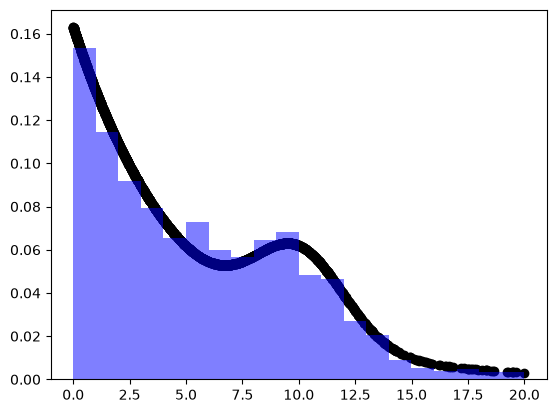

In [6]:
#plt.scatter(x,f(x,theta_true,mu_true,sigma_true,xi_true),label='pdf',color='black')
plt.scatter(x,g(x,theta_true,mu_true,sigma_true,xi_true),label='pdf',color='black')
plt.hist(x, bins=20,density=True, alpha=0.5, label='data', color='blue')

Defining a Negative Log likelihood function.

In [7]:
def neg_log_likelihood(par):
    theta=par[0]
    mu=par[1]
    sigma=par[2]
    xi=par[3]
    if sigma <= 0 or xi <= 0 or theta < 0 or theta > 1:
        return np.inf  # Return infinity for invalid parameter values
    pdf_values = f(x, par)
    log_likelihood = np.sum(np.log(pdf_values))
    return -log_likelihood
  

Parameter initialization, also we choose which parameters are allowed to vary.

In [8]:
parin=np.array([0.01, 10.0, 2.0, 20.0])
parname=['theta','mu','sigma','xi']
parnamelatex=[r'$\theta$',r'$\mu$',r'$\sigma$',r'$\xi$']

parstep = np.array([0.1, 1., 1., 1.]) # initial setp sizes
parfix = [False, True, True, False] # change these to fix/free parameters
parlim = [(0.,1), (None, None), (0., None), (0., None)] # set limits
m = Minuit(neg_log_likelihood, parin, name=parname)
m.errors = parstep
m.fixed = parfix
m.limits = parlim
m.errordef = 0.5 # errors from lnL = lnLmax - 0.5

Now we use Minuit to calculate the descriptive statistics i.e. mean, covariance and correlation of the parameters that are actually free.

In [9]:
m.migrad()                                        
MLE = m.values                                    
sigmaMLE = m.errors                               
cov = m.covariance                                
rho = m.covariance.correlation()                  
    
print(r"par index, name, estimate, standard deviation:")
for i in range(m.npar):
    if not m.fixed[i]:
        print("{:4d}".format(i), "{:<10s}".format(m.parameters[i]), " = ",
         "{:.6f}".format(MLE[i]), " +/- ", "{:.6f}".format(sigmaMLE[i]))

print()
print(r"free par indices, covariance, correlation coeff.:")
for i in range(m.npar):
    if not(m.fixed[i]):
        for j in range(m.npar):
            if not(m.fixed[j]):
                print(i, j, "{:.6f}".format(cov[i,j]), "{:.6f}".format(rho[i,j]))



par index, name, estimate, standard deviation:
   0 theta       =  0.203002  +/-  0.016433
   3 xi          =  4.858602  +/-  0.192030

free par indices, covariance, correlation coeff.:
0 0 0.000270 1.000000
0 3 -0.001704 -0.539675
3 0 -0.001704 -0.539675
3 3 0.036877 1.000000


We are now going to plot the data using the parameter values derived from our ML calculations above. The ticks on the bottom are just binned data.

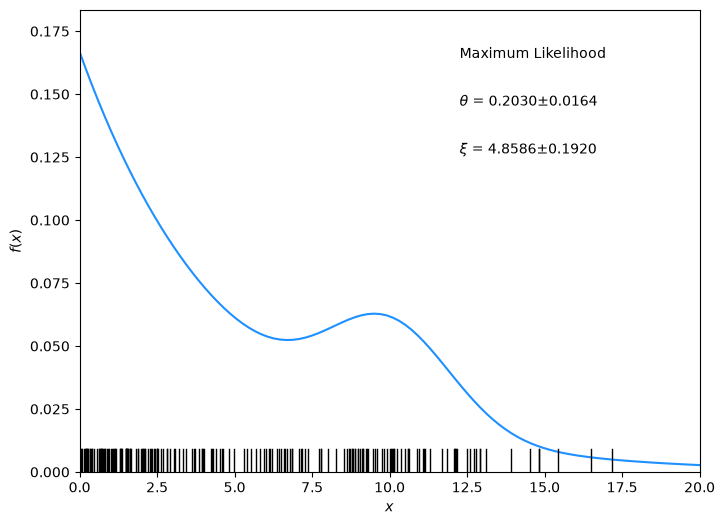

In [10]:

yMin = 0.
yMax = f(0., MLE)*1.1
fig = plt.figure(figsize=(8,6))
xCurve = np.linspace(xMin, xMax, 100)
yCurve = f(xCurve, MLE)
plt.plot(xCurve, yCurve, color='dodgerblue')
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
y_fitval = 0.8
delta_y_fitval = 0.08
plt.figtext(0.6, y_fitval, 'Maximum Likelihood')
for i in range(len(parin)):
    if not parfix[i]:
        y_fitval -= delta_y_fitval
        plt.figtext(0.6, y_fitval, parnamelatex[i] + ' = ' + f'{MLE[i]:.4f}' + r'$\pm$' + f'{sigmaMLE[i]:.4f}')
        
# Plot data as tick marks
tick_height = 0.05*(yMax - yMin)
xvals = [xData, xData]
yvals = [np.zeros_like(xData), tick_height * np.ones_like(xData)]
plt.plot(xvals, yvals, color='black', linewidth=1)
plt.xlim(xMin, xMax)
plt.ylim(yMin, yMax)
plt.show()



Now using miniut we calculate the profile likelihood i.e. to find the best fitted value of our parameter we minimize the other parameters(may be nuisance).

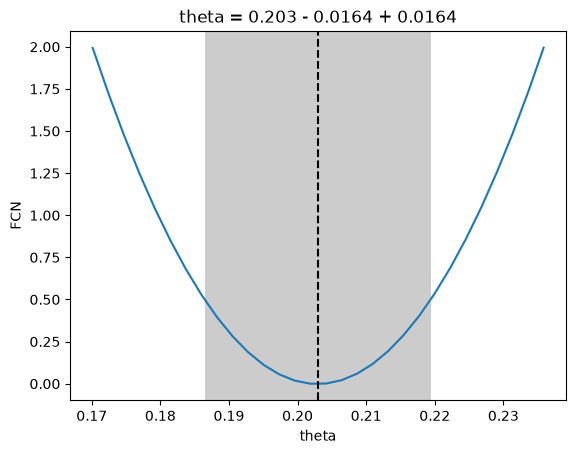

In [11]:
# Make scan of lnL (for theta, if free)
if not(m.fixed['theta']):
    plt.figure()
    m.draw_mnprofile('theta')
    plt.show()

An important part of our observations is confidence interval. Confidence intervals gives us a range within which the true value of the parameter is supposed to fall when we take many many observations. Also the tangent to such contours give us the standard deviation.

CL =  0.3934693402873665


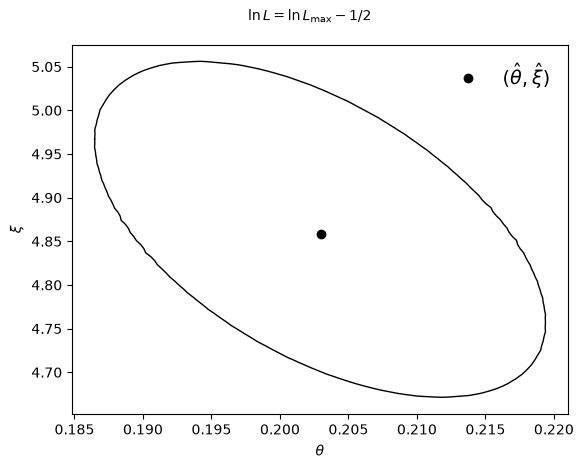

In [12]:
CL = stats.chi2.cdf(1.,2)          
print('CL = ', CL)
if not(m.fixed['theta'] | m.fixed['xi']):
    fig, ax = plt.subplots(1,1)
    con = m.mncontour('theta', 'xi', cl=CL, size=200)
    con = np.vstack([con, con[0]])         # close contour
    plt.plot(MLE[0], MLE[3], marker='o', linestyle='None', color='black', label=r'$(\hat{\theta}, \hat{\xi})$')
    plt.plot(con[:,0], con[:,1], color='black', linewidth=1)
    plt.xlabel(r'$\theta$', labelpad=5)
    plt.ylabel(r'$\xi$', labelpad=5)
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles, labels, loc='upper right', fontsize=14, frameon=False)
    plt.figtext(0.4, 0.93, r'$\ln L = \ln L_{\rm max} - 1/2$')
    plt.show()

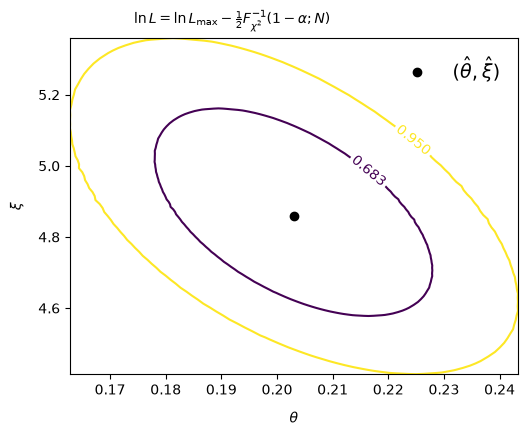

In [13]:
# Confidence region from lnL = lnLmax - Q/2 (here for theta and xi)
# where Q is the chi2 quantile of CL = 1-alpha = 0.683 and 0.95 for 2 dof.
if not(m.fixed['theta'] | m.fixed['xi']):
    fig, ax = plt.subplots(1,1)
    m.draw_mncontour('theta', 'xi', cl=[0.683, 0.95], size=200);
    plt.plot(MLE[0], MLE[3], marker='o', linestyle='None', color='black', label=r'$(\hat{\theta}, \hat{\xi})$')
    plt.xlabel(r'$\theta$', labelpad=10)
    plt.ylabel(r'$\xi$', labelpad=10)
    plt.subplots_adjust(left=0.2, right=0.9, top=0.9, bottom=0.2)
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles, labels, loc='upper right', fontsize=14, frameon=False)
    plt.figtext(0.3, 0.93, r'$\ln L = \ln L_{\rm max} - \frac{1}{2} F^{-1}_{\chi^2}(1-\alpha;N)$')
    plt.show()

Part b and c:
Here we have to show that the standard deviation of our estimated parameter or parameters go dowe as $\frac{1}{\sqrt n}$ where n is the sample size.

In [14]:
# Sample sizes
n_values=np.array([10, 20, 50, 100, 200, 500, 1000, 2000])

# Store errors
std_theta=[]
std_xi=[]

# True parameters used to generate the data
true_par=np.array([theta_true, mu_true, sigma_true, xi_true])

for n_i in n_values:

    t=np.empty(n_i)

    for i in range(n_i):

        r = np.random.uniform()

        if r < theta_true:
            t[i] = truncnorm.rvs(
                a=(xMin-mu_true)/sigma_true,
                b=(xMax-mu_true)/sigma_true,
                loc=mu_true,
                scale=sigma_true
            )
        else:
            t[i] = truncexpon.rvs(
                b=(xMax-xMin)/xi_true,
                loc=xMin,
                scale=xi_true
            )

    def nll(theta, mu, sigma, xi):

        if not (0 < theta < 1):
            return np.inf

        if sigma <= 0 or xi <= 0:
            return np.inf

        pdf_values = f(t, [theta, mu, sigma, xi])

        # Protect against log(0)
        if np.any(~np.isfinite(pdf_values)) or np.any(pdf_values <= 0):
            return np.inf

        return -np.sum(np.log(pdf_values))

    m = Minuit(nll,theta=0.2,mu=mu_true,sigma=sigma_true,xi=xi_true)
    m.fixed["mu"] = True
    m.fixed["sigma"] = True
    m.limits["theta"] = (1e-6, 1 - 1e-6)
    m.limits["xi"] = (1e-6, None)
    m.errordef = 0.5
    m.migrad()

    # Check that minimization worked
    if not m.fmin.is_valid:
        print(f"Warning: minimization failed for n = {n_i}")
        std_theta.append(np.nan)
        std_xi.append(np.nan)
        continue

    std_theta.append(m.errors["theta"])
    std_xi.append(m.errors["xi"])

std_theta = np.array(std_theta)
std_xi = np.array(std_xi)

print("std_theta =", std_theta)
print("std_xi    =", std_xi)

std_theta = [0.22222892 0.64664958 0.09041868 0.06699282 0.0514927  0.03304173
 0.02290757 0.01631451]
std_xi    = [2.55992605 2.51947013 0.82561093 0.75955774 0.64377951 0.37680812
 0.2709455  0.21153947]


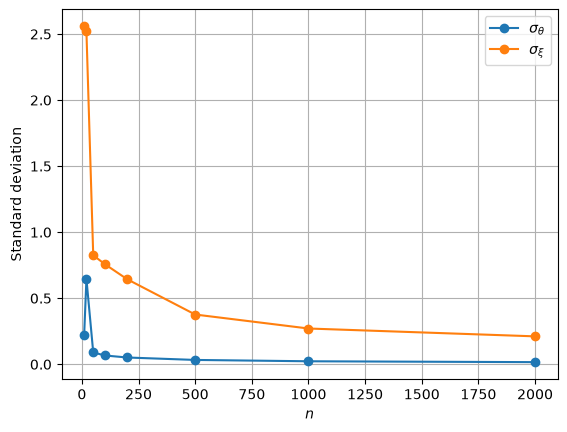

In [15]:
plt.figure()

plt.plot(n_values,std_theta,'o-',label=r'$\sigma_\theta$')
plt.plot(n_values,std_xi,'o-',label=r'$\sigma_\xi$')
plt.xlabel(r'$n$')
plt.ylabel('Standard deviation')
plt.legend()
plt.grid(True, which='both')
plt.show()

In [16]:
n_val=200



# True parameters used to generate the data
true_par=np.array([theta_true, mu_true, sigma_true, xi_true])


t=np.empty(n_val)

for i in range(0,n_val):

    r = np.random.uniform()

    if r < theta_true:
        t[i] = truncnorm.rvs(a=(xMin-mu_true)/sigma_true,b=(xMax-mu_true)/sigma_true,loc=mu_true,scale=sigma_true)
    else:
        t[i] = truncexpon.rvs(b=(xMax-xMin)/xi_true,loc=xMin,scale=xi_true)

def nll(theta, mu, sigma, xi):

    if not (0 < theta < 1):
        return np.inf

    if sigma <= 0 or xi <= 0:
        return np.inf

    pdf_values = f(t, [theta, mu, sigma, xi])

    # Protect against log(0)
    if np.any(~np.isfinite(pdf_values)) or np.any(pdf_values <= 0):
        return np.inf

    return -np.sum(np.log(pdf_values))

m = Minuit(nll,theta=0.2,mu=mu_true,sigma=sigma_true,xi=xi_true)
m.fixed["mu"] = True
m.fixed["sigma"] = True
m.fixed["xi"] = True
m.limits["theta"] = (1e-6, 1 - 1e-6)
m.errordef = 0.5
m.migrad()
std_theta=m.errors["theta"]

std_Theta=[]

print("Only theta is free")
std_Theta.append(std_theta)
print(std_theta)
print("\n")

m = Minuit(nll,theta=0.2,mu=mu_true,sigma=sigma_true,xi=xi_true)
m.fixed["mu"] = True
m.fixed["sigma"] = True
m.limits["theta"] = (1e-6, 1 - 1e-6)
m.limits["xi"] = (1e-6, None)
m.errordef = 0.5
m.migrad()
std_theta=m.errors["theta"]

print("xi and theta are free")
std_Theta.append(std_theta)
print(std_theta)
print("\n")

m = Minuit(nll,theta=0.2,mu=mu_true,sigma=sigma_true,xi=xi_true)
m.fixed["mu"] = True
m.limits["theta"] = (1e-6, 1 - 1e-6)
m.limits["xi"] = (1e-6, None)
m.limits["sigma"] = (0, None)
m.errordef = 0.5
m.migrad()
std_theta=m.errors["theta"]

print("xi,theta and sigma is free")
std_Theta.append(std_theta)
print(std_theta)
print("\n")

m = Minuit(nll,theta=0.2,mu=mu_true,sigma=sigma_true,xi=xi_true)
m.limits["theta"] = (1e-6, 1 - 1e-6)
m.limits["xi"] = (1e-6, None)
m.limits["sigma"] = (0, None)
m.limits["mu"] = (None, None)

m.errordef = 0.5
m.migrad()
std_theta=m.errors["theta"]
print("Only theta is free")
std_Theta.append(std_theta)
print(std_theta)


Only theta is free
0.0402554236106334


xi and theta are free
0.04977964237697348


xi,theta and sigma is free
0.09483485699773876


Only theta is free
0.11784691900103544


[0.0402554236106334, 0.04977964237697348, 0.09483485699773876, 0.11784691900103544]


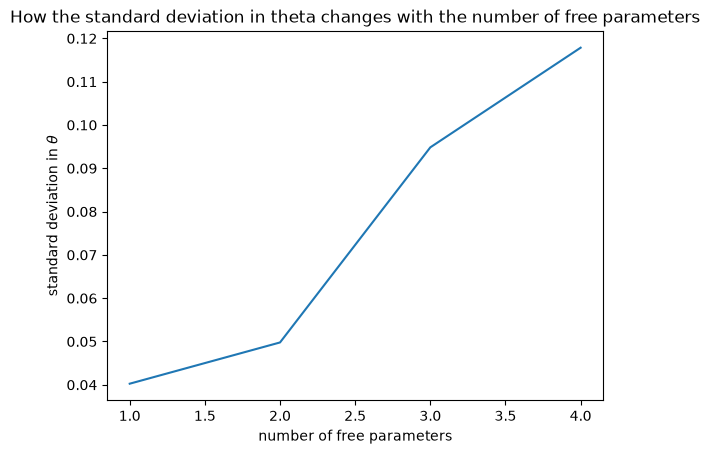

In [26]:
print(std_Theta)
n=[1,2,3,4]
plt.plot(n,std_Theta)
plt.title("How the standard deviation in theta changes with the number of free parameters")
plt.xlabel("number of free parameters")
plt.ylabel(r"standard deviation in $\theta$")
plt.show()

Part e:
The parameters theta and xi are fixed where as sigma and mu are fixed. We have an estimate about xi in form of a dataset u. u follows Gaussian distribution with mean xi and standard deviation 0.5.


In [22]:
# define pdf and generate data
np.random.seed(seed=1234567)  
theta_true = 0.2
mu_true = 10.0
sigma_true = 2.0
xi_true = 5+(np.random.uniform(0,1)-0.5)  # Assuming xi_true follows a normal distribution with mean 5 and std dev 0.5

xMin = 0.0
xMax = 20.0
numVal = 2000

x=np.zeros(numVal)

def f(x, par):
    theta   = par[0]
    mu      = par[1]
    sigma   = par[2]
    xi      = par[3]
    fs = stats.truncnorm.pdf(x, a=(xMin-mu)/sigma, b=(xMax-mu)/sigma, loc=mu, scale=sigma)
    fb = stats.truncexpon.pdf(x, b=(xMax-xMin)/xi, loc=xMin, scale=xi)
    return theta*fs + (1-theta)*fb

for i in range(numVal):
    a=np.random.uniform(0,1)
    if a<theta_true:
        x[i] = truncnorm.rvs(a=(xMin-mu_true)/sigma_true, b=(xMax-mu_true)/sigma_true, loc=mu_true, scale=sigma_true)
    else:
        x[i] = truncexpon.rvs(b=(xMax-xMin)/xi_true, loc=xMin, scale=xi_true)
print(x)

[5.88547884 0.48855882 8.36833653 ... 0.41833415 3.78285129 0.69937737]


There's slight modification in Likelihood function. As we have information about xi we can write our new likelihood as a product of the old and the "correction". If one calculates we can just see the adiitional term in our negative log likelihood is a normally distributed random variate with mean 5 and standard deviation 0.5

In [45]:
def neg_log_likelihoodadditional(par):
    theta = par[0]
    mu = par[1]
    sigma = par[2]
    xi = par[3]
    
    # Boundary checks
    if sigma <= 0 or xi <= 0 or theta < 0 or theta > 1:
        return np.inf  
        
    # 1. Primary data log-likelihood
    pdf_values = f(x, par)
    primary_log_likelihood = np.sum(np.log(pdf_values)) 
    
    # 2. Auxiliary measurement log-likelihood
    # We evaluate the log-PDF of the observed value (u = 5) given the parameter mean (xi)
    auxiliary_log_likelihood = stats.norm.logpdf(5, loc=xi, scale=0.5)
    
    # 3. Total Negative Log-Likelihood (Multiplication becomes addition)
    total_log_likelihood = primary_log_likelihood + auxiliary_log_likelihood
    
    return -total_log_likelihood


In [46]:
def neg_log_likelihood(par):
    theta=par[0]
    mu=par[1]
    sigma=par[2]
    xi=par[3]
    if sigma <= 0 or xi <= 0 or theta < 0 or theta > 1:
        return np.inf  # Return infinity for invalid parameter values
        
    
    #additional=stats.normal(loc=5, scale=0.5)  # Assuming a standard normal distribution for correction
    pdf_values = f(x, par)
    log_likelihood = np.sum(np.log(pdf_values))
    return -log_likelihood

In [47]:
parin=np.array([0.01, 10.0, 2.0, 20.0])
parname=['theta','mu','sigma','xi']
parnamelatex=[r'$\theta$',r'$\mu$',r'$\sigma$',r'$\xi$']

parstep = np.array([0.1, 1., 1., 1.]) # initial setp sizes
parfix = [False, True, True, False] # change these to fix/free parameters
parlim = [(0.,1), (None, None), (0., None), (0., None)] # set limits
m = Minuit(neg_log_likelihood, parin, name=parname)

m.errors = parstep
m.fixed = parfix
m.limits = parlim
m.errordef = 0.5 # errors from lnL = lnLmax - 0.5

In [48]:
m.migrad()                                        
MLE = m.values                                    
sigmaMLE = m.errors                               
cov = m.covariance                                
rho = m.covariance.correlation()                  
    
print(r"par index, name, estimate, standard deviation:")
for i in range(m.npar):
    if not m.fixed[i]:
        print("{:4d}".format(i), "{:<10s}".format(m.parameters[i]), " = ",
         "{:.6f}".format(MLE[i]), " +/- ", "{:.6f}".format(sigmaMLE[i]))

print()
print(r"free par indices, covariance, correlation coeff.:")
for i in range(m.npar):
    if not(m.fixed[i]):
        for j in range(m.npar):
            if not(m.fixed[j]):
                print(i, j, "{:.6f}".format(cov[i,j]), "{:.6f}".format(rho[i,j]))



par index, name, estimate, standard deviation:
   0 theta       =  0.206850  +/-  0.016324
   3 xi          =  4.675831  +/-  0.188200

free par indices, covariance, correlation coeff.:
0 0 0.000267 1.000000
0 3 -0.001717 -0.558803
3 0 -0.001717 -0.558803
3 3 0.035420 1.000000


In [49]:
parin=np.array([0.01, 10.0, 2.0, 20.0])
parname=['theta','mu','sigma','xi']
parnamelatex=[r'$\theta$',r'$\mu$',r'$\sigma$',r'$\xi$']

parstep = np.array([0.1, 1., 1., 1.]) # initial setp sizes
parfix = [False, True, True, False] # change these to fix/free parameters
parlim = [(0.,1), (None, None), (0., None), (0., None)] # set limits
m = Minuit(neg_log_likelihoodadditional, parin, name=parname)

m.errors = parstep
m.fixed = parfix
m.limits = parlim
m.errordef = 0.5 # errors from lnL = lnLmax - 0.5

In [50]:
m.migrad()                                        
MLE = m.values                                    
sigmaMLE = m.errors                               
cov = m.covariance                                
rho = m.covariance.correlation()                  
    
print(r"par index, name, estimate, standard deviation:")
for i in range(m.npar):
    if not m.fixed[i]:
        print("{:4d}".format(i), "{:<10s}".format(m.parameters[i]), " = ",
         "{:.6f}".format(MLE[i]), " +/- ", "{:.6f}".format(sigmaMLE[i]))

print()
print(r"free par indices, covariance, correlation coeff.:")
for i in range(m.npar):
    if not(m.fixed[i]):
        for j in range(m.npar):
            if not(m.fixed[j]):
                print(i, j, "{:.6f}".format(cov[i,j]), "{:.6f}".format(rho[i,j]))



par index, name, estimate, standard deviation:
   0 theta       =  0.204880  +/-  0.016059
   3 xi          =  4.716579  +/-  0.178741

free par indices, covariance, correlation coeff.:
0 0 0.000258 1.000000
0 3 -0.001539 -0.535916
3 0 -0.001539 -0.535916
3 3 0.031950 1.000000


As we can see both the mean and standard deviations became sharper as a cosequence of our knowledge about xi.